<a href="https://colab.research.google.com/github/entropy-om/entheai/blob/rahul-phi-work/Rahul_rangarao_phi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch unsloth transformers datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/

In [2]:
!pip install peft bitsandbytes trl accelerate

In [3]:
# Install a font that supports a wide range of Unicode characters (e.g., WenQuanYi Zen Hei CJK font)
!sudo apt-get install -y fonts-wqy-zenhei

# Clear matplotlib's font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-wqy-zenhei
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 7,472 kB of archives.
After this operation, 16.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-wqy-zenhei all 0.9.45-8 [7,472 kB]
Fetched 7,472 kB in 4s (1,967 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-wqy-zenhei.
(Reading database ... 12240

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/Phi-4-mini-instruct

What im trying to do:

In [1]:
from transformers import pipeline
from torch import nn
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")

model_id = "microsoft/Phi-4-mini-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, device_map="auto"
    ,torch_dtype=torch.bfloat16       # bf16 → ~7.7 GB instead of ~15 GB
)

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [4]:
print(model.lm_head)  # Linear(in_features=hidden_size, out_features=vocab_size, bias=False)

# Freeze the backbone — only train the new head
for param in model.model.parameters():
    param.requires_grad = False

hidden_size = model.config.hidden_size
vocab_size = model.config.vocab_size

Linear(in_features=3072, out_features=200064, bias=False)


In [5]:
class CustomLMHead(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.proj1 = nn.Linear(hidden_size, hidden_size)
        self.act = nn.GELU()
        self.norm = nn.LayerNorm(hidden_size)
        self.proj2 = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, hidden_states):
        # Ensure hidden_states match the weight dtype (e.g., BFloat16)
        dtype = self.proj1.weight.dtype
        x = hidden_states.to(dtype)
        x = self.act(self.proj1(x))
        x = self.norm(x)
        return self.proj2(x)

# Re-apply the head to the model
# model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [6]:
def generate_with_custom_sampling(model, tokenizer, prompt, max_new_tokens=50,
                                    temperature=0.8, top_k=42, top_p=0.8,
                                    repetition_penalty=1.1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated = inputs["input_ids"]
    step_probs = [] # To store the probability of the chosen token at each step

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        for token_id in set(generated[0].tolist()):
            logits[0, token_id] /= repetition_penalty

        top_k_vals, top_k_idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(1, top_k_idx, top_k_vals)

        probs = torch.softmax(filtered, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # Capture the probability of the token that was actually picked
        actual_prob = probs[0, next_token.item()].item()
        step_probs.append(actual_prob)

        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=False), probs, generated, step_probs

In [7]:
messages = [
      {"role": "user", "content": "Who are you? Who am I?"},
  ]

inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
  ).to(model.device)

In [8]:
outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I am Phi, an AI developed by Microsoft. You are a user interacting with me. How can I assist you today?


It is definitely gibberish, It needs to be trained on "Rahul"

In [9]:
all_data_distri, last_step_probs, generated, token_probs = generate_with_custom_sampling(model, tokenizer, prompt=messages[0]['content'])

# Prepare data for DataFrame
prompt_len = tokenizer(messages[0]['content'], return_tensors="pt")["input_ids"].shape[1]
gen_tokens = generated[0][prompt_len:]

data = []
for i, (t_id, p) in enumerate(zip(gen_tokens, token_probs)):
    data.append({
        'position': i,
        'token_id': t_id.item(),
        'token_text': tokenizer.decode([t_id]),
        'probability': p
    })

df_results = pd.DataFrame(data)
display(df_results)

,position,token_id,token_text,probability
0,0,23298,Such,0.006165
1,1,5359,questions,0.894531
2,2,11,",",0.121094
3,3,1118,which,0.175781
4,4,679,have,0.265625
5,5,1701,long,0.056396
6,6,88679,fascinated,0.079590
7,7,137441,philosophers,0.695312
8,8,328,of,0.016724
9,9,4246,mind,0.753906


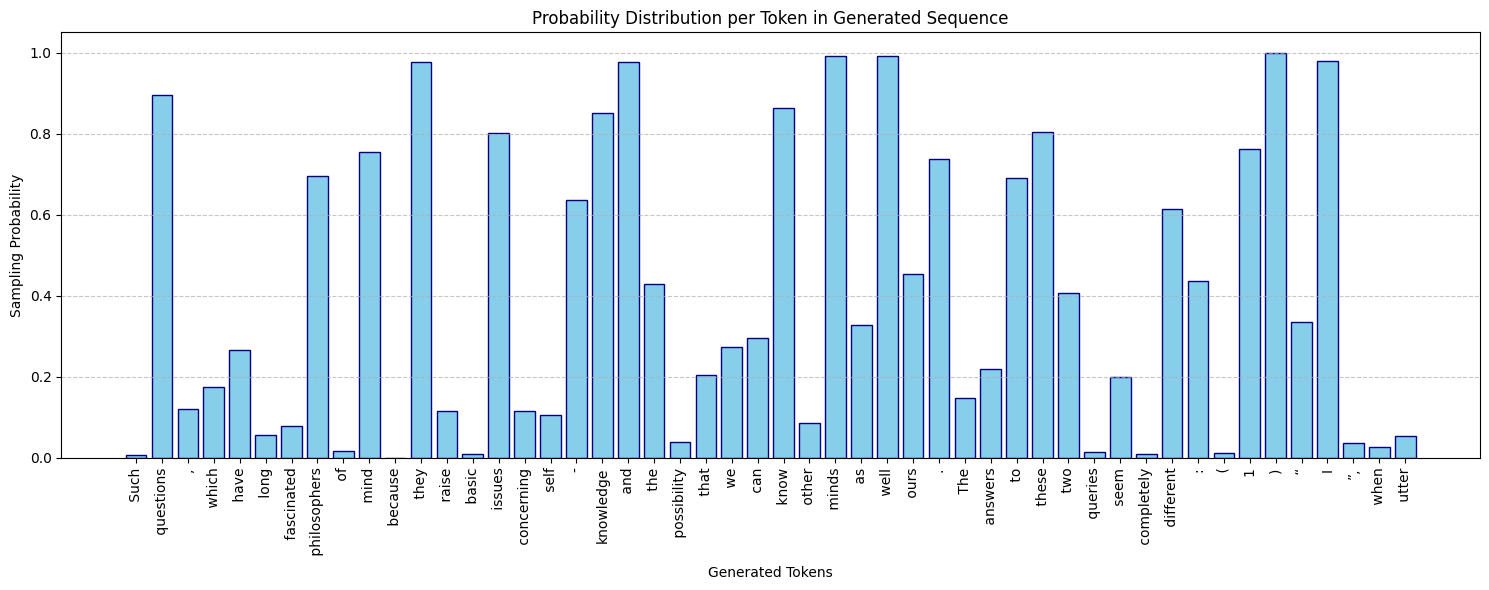

In [10]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib.font_manager')

plt.figure(figsize=(15, 6))
plt.bar(df_results['position'], df_results['probability'], color='skyblue', edgecolor='navy')
plt.xticks(df_results['position'], df_results['token_text'], rotation=90)
plt.xlabel('Generated Tokens')
plt.ylabel('Sampling Probability')
plt.title('Probability Distribution per Token in Generated Sequence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
all_data_distri

'Who are you? Who am I? Such questions, which have long fascinated philosophers of mind because they raise basic issues concerning self-knowledge and the possibility that we can know other minds as well ours. The answers to these two queries seem completely different: (1) “I”, when utter'

In [12]:
len(gen_tokens)==len(token_probs)

True

In [13]:
print(last_step_probs[last_step_probs > 0])

tensor([5.9128e-04, 1.9531e-02, 4.3640e-03, 3.5858e-04, 1.1841e-02, 8.7402e-02,
        9.7275e-04, 4.3640e-03, 1.6022e-03, 5.9128e-04, 4.3640e-03, 6.4844e-01,
        4.3640e-03, 5.9128e-04, 5.9128e-04, 1.6022e-03, 3.5858e-04, 1.6022e-03,
        3.5858e-04, 4.3640e-03, 1.6022e-03, 2.6398e-03, 1.6022e-03, 5.9128e-04,
        2.6398e-03, 9.7275e-04, 5.9128e-04, 1.6022e-03, 1.1841e-02, 1.6022e-03,
        4.3640e-03, 1.6022e-03, 1.6022e-03, 8.7402e-02, 5.3223e-02, 5.9128e-04,
        1.9531e-02, 5.9128e-04, 2.6398e-03, 2.6398e-03, 5.9128e-04, 1.6022e-03],
       device='cuda:0', dtype=torch.bfloat16)


In [14]:
last_step_probs[last_step_probs>0]

tensor([5.9128e-04, 1.9531e-02, 4.3640e-03, 3.5858e-04, 1.1841e-02, 8.7402e-02,
        9.7275e-04, 4.3640e-03, 1.6022e-03, 5.9128e-04, 4.3640e-03, 6.4844e-01,
        4.3640e-03, 5.9128e-04, 5.9128e-04, 1.6022e-03, 3.5858e-04, 1.6022e-03,
        3.5858e-04, 4.3640e-03, 1.6022e-03, 2.6398e-03, 1.6022e-03, 5.9128e-04,
        2.6398e-03, 9.7275e-04, 5.9128e-04, 1.6022e-03, 1.1841e-02, 1.6022e-03,
        4.3640e-03, 1.6022e-03, 1.6022e-03, 8.7402e-02, 5.3223e-02, 5.9128e-04,
        1.9531e-02, 5.9128e-04, 2.6398e-03, 2.6398e-03, 5.9128e-04, 1.6022e-03],
       device='cuda:0', dtype=torch.bfloat16)

Actual finetuning starts here!


In [15]:
from peft import LoraConfig, prepare_model_for_kbit_training

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")

model_id = "microsoft/Phi-4-mini-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

In [16]:
from datasets import load_dataset

data = load_dataset("json", data_files={
    "train": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/train.jsonl",
    "validation": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/valid.jsonl",
    "test": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/test.jsonl",
})

In [17]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

Going back to the original once more

In [18]:
# Re-apply preparation and custom head since the model was re-initialized
model = prepare_model_for_kbit_training(model)
#model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [20]:
sft_config = SFTConfig(
    output_dir="/content/adapters",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=25,
    learning_rate=1e-4,
    eval_strategy="steps",
    eval_steps=25,
    logging_steps=10,
    bf16=True,
    packing=False,
)


sft_config.save_strategy = "steps"
sft_config.save_steps = 25
sft_config.load_best_model_at_end = True
sft_config.metric_for_best_model = "eval_loss"
sft_config.greater_is_better = False

In [21]:
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=data["train"],
    eval_dataset=data["test"],
    peft_config=lora_config,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.646116,1.548234,1.463319,131829.000000,0.632453
50,1.404176,1.464599,1.335326,257575.000000,0.644314
75,1.222167,1.454524,1.228762,387760.000000,0.644854
100,1.022630,1.521813,1.055169,519179.000000,0.643927
125,0.860993,1.769709,0.856742,648047.000000,0.629597
150,0.603000,1.937809,0.781725,775520.000000,0.623334
175,0.394797,2.256849,0.632575,906562.000000,0.615214
200,0.237545,2.861216,0.514319,1036013.000000,0.601166
225,0.130750,2.871836,0.490965,1163280.000000,0.601532
250,0.066100,3.377349,0.431132,1293232.000000,0.594066


TrainOutput(global_step=375, training_loss=0.5438070129354795, metrics={'train_runtime': 903.2953, 'train_samples_per_second': 3.266, 'train_steps_per_second': 0.415, 'total_flos': 5.076201363884851e+16, 'train_loss': 0.5438070129354795, 'epoch': 25.0})

In [22]:
messages = [
      {"role": "user", "content": "Who are you? Who am I?"},
  ]

inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
  ).to(device=model.device)

In [24]:
outputs = model.generate(**inputs)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=31) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


RuntimeError: expected scalar type Float but found BFloat16

In [ ]:
drive_path = "/content/drive/MyDrive/Colab Notebooks/rahul-ai/adapters"
trainer.save_model(drive_path)
tokenizer.save_pretrained(drive_path)

In [ ]:
!mkdir -p "/content/drive/MyDrive/Colab Notebooks/rahul-ai/adapters-checkpoints"
!cp -r /content/adapters/* "/content/drive/MyDrive/Colab Notebooks/rahul-ai/adapter-checkpoints/"

In [ ]:
from peft import PeftModel, prepare_model_for_kbit_training

# 1. Update Config for BFloat16 to match model weights
sft_config = SFTConfig(
    output_dir="/content/adapters",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=15,
    learning_rate=5e-5,
    eval_strategy="steps",
    eval_steps=25,
    logging_steps=10,
    bf16=True,  # Set to True to resolve Float vs BFloat16 mismatch
    optim="paged_adamw_8bit",
    packing=False,
)

# 2. Re-prepare model for k-bit training
model = prepare_model_for_kbit_training(model)

# 3. Re-define and re-attach CustomLMHead with explicit dtype casting in forward pass
class CustomLMHead(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.proj1 = nn.Linear(hidden_size, hidden_size)
        self.act = nn.GELU()
        self.norm = nn.LayerNorm(hidden_size)
        self.proj2 = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, hidden_states):
        # Fix: Cast hidden_states to match the layer's weights (BFloat16)
        target_dtype = self.proj1.weight.dtype
        x = hidden_states.to(target_dtype)
        x = self.act(self.proj1(x))
        x = self.norm(x)
        return self.proj2(x)

model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [ ]:
trainer = SFTTrainer(
    model=model,              # same model object — already has your trained adapters
    args=sft_config,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    peft_config=lora_config,
)
trainer.train()

custom experimentation...

In [ ]:
# Force the lm_head to bfloat16 to match the backbone weights and prevent the RuntimeError
model.lm_head.to(dtype=torch.bfloat16)
print(f"Model head dtype: {model.lm_head.weight.dtype}")

In [ ]:
def generate_with_custom_sampling(model, tokenizer, prompt, max_new_tokens=50,
                                    temperature=0.8, top_k=42, top_p=0.8,
                                    repetition_penalty=1.1):
    # Ensure model is in the right mode
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Ensure input_ids are long, but hidden state logic inside model will need bf16
    generated = inputs["input_ids"]
    step_probs = []

    for _ in range(max_new_tokens):
        with torch.no_grad():
            # The forward pass generates hidden states.
            # We ensure the model uses its preferred dtype (bfloat16)
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        for token_id in set(generated[0].tolist()):
            logits[0, token_id] /= repetition_penalty

        top_k_vals, top_k_idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(1, top_k_idx, top_k_vals)

        probs = torch.softmax(filtered.to(torch.float32), dim=-1) # Softmax in float32 for stability
        next_token = torch.multinomial(probs, num_samples=1)

        actual_prob = probs[0, next_token.item()].item()
        step_probs.append(actual_prob)

        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=False), probs, generated, step_probs

In [34]:

all_data_distri, last_step_probs, generated, token_probs = generate_with_custom_sampling(model, tokenizer, prompt=messages[0]['content'])

# Prepare data for DataFrame
prompt_len = tokenizer(messages[0]['content'], return_tensors="pt")["input_ids"].shape[1]
gen_tokens = generated[0][prompt_len:]

data_list = []
for i, (t_id, p) in enumerate(zip(gen_tokens, token_probs)):
    data_list.append({
        'position': i,
        'token_id': t_id.item(),
        'token_text': tokenizer.decode([t_id]),
        'probability': p
    })

df_results = pd.DataFrame(data_list)
display(df_results)

RuntimeError: expected mat1 and mat2 to have the same dtype, but got: float != c10::BFloat16

In [29]:
all_data_distri

'Who are you? Who am I? Chapel rooft QPoint felly forb اش möj/plainន្ល-edfügbłę以 legge राज्यों identiteit Poly lojestos AguilParas fehlen Leider girls养官方网址ოდისవి competing аҳәа মহান removes identiteitzustalore maje támogatіс اړه болestruct leedxmlnsოდისіс françaises legge Sharon(heroଆ'

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
